# Predicción de abandono de clientes

### Caso Netflix: https://www.kaggle.com/datasets/abdulwadood11220/netflix-customer-churn-dataset

In [3]:
import pandas as pd

In [4]:
df_netflix = pd.read_csv('C:/Portfolio/churn_models/input/netflix_customer_churn.csv')

In [5]:
df_netflix.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [6]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [19]:
X = df_netflix.drop(columns=['churned', 'customer_id'])
y = df_netflix['churned']

In [20]:
X.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(f"Training set size: {len(X_train)*100/len(X)}%")

Training set size: 80.0%


In [24]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [25]:
label_encoder = LabelEncoder()
standard_scaler = StandardScaler()

In [26]:
categorical_features = X.select_dtypes(include=['object']).columns
categorical_features

Index(['gender', 'subscription_type', 'region', 'device', 'payment_method',
       'favorite_genre'],
      dtype='object')

In [27]:
for col in categorical_features:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

X_train.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4227,54,2,1,9.80,56,3,4,17.99,1,4,0.17,5
4676,31,2,0,10.38,42,3,4,8.99,2,1,0.24,0
800,59,2,0,20.13,6,0,2,8.99,0,1,2.88,3
3671,45,0,0,9.77,16,1,1,8.99,3,2,0.57,5
4193,36,1,2,9.10,2,3,4,13.99,2,2,3.03,3


In [30]:
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,0.647676,1.237215,0.015693,-0.159483,1.480115,0.278164,1.392455,1.166222,-0.726280,0.694786,-0.264476,0.980574
1,-0.838302,1.237215,-1.215140,-0.111776,0.681725,0.278164,1.392455,-1.261441,-0.016676,-1.426697,-0.238574,-1.527929
2,0.970715,1.237215,-1.215140,0.690195,-1.371277,-1.480513,-0.026427,-1.261441,-1.435884,-1.426697,0.738293,-0.022827
3,0.066207,-1.202450,-1.215140,-0.161951,-0.800999,-0.894287,-0.735867,-1.261441,0.692928,-0.719536,-0.116466,0.980574
4,-0.515263,0.017383,1.246527,-0.217060,-1.599388,0.278164,1.392455,0.087261,-0.016676,-0.719536,0.793797,-0.022827


In [31]:
# Modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression

In [32]:
log_reg = LogisticRegression()

In [ ]:
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred_log_reg = log_reg.predict(X_test_scaled)

In [36]:
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

c:\Portfolio\churn_models\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [42]:
len(X_train)

4000

In [41]:
len(X_test)

1000

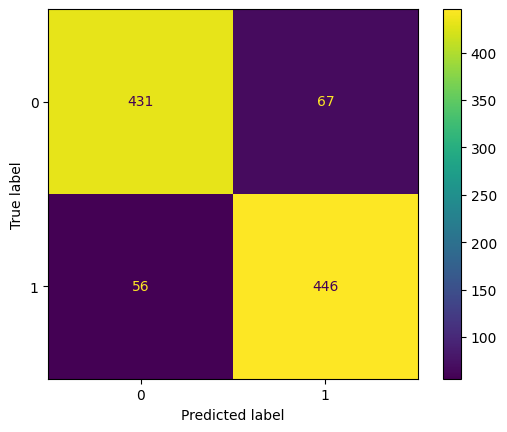

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log_reg)
ConfusionMatrixDisplay(cm).plot()

In [70]:
(56+67)*100/(1000)

12.3

In [69]:
importance = log_reg.coef_[0]
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
4,last_login_days,2.106871
5,region,0.071294
0,age,0.013351
11,favorite_genre,0.002642
8,payment_method,-0.028161
6,device,-0.030263
1,gender,-0.068106
2,subscription_type,-0.478728
7,monthly_fee,-0.570628
9,number_of_profiles,-0.972962


In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

random_forest.fit(X_train_scaled, y_train)

y_pred_random_forest = random_forest.predict(X_test_scaled)

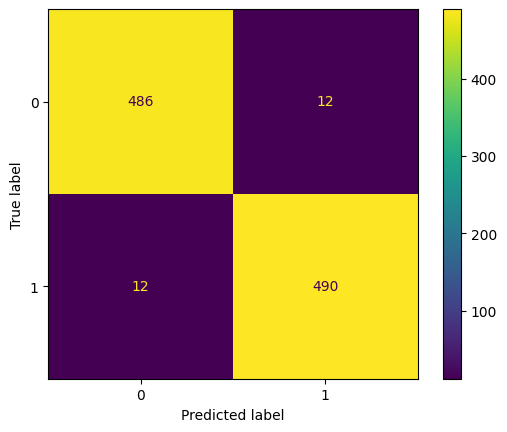

In [48]:
cm = confusion_matrix(y_test, y_pred_random_forest)
ConfusionMatrixDisplay(cm).plot()

In [72]:
# Importancia de características para Random Forest
importance_rf = random_forest.feature_importances_
features = X_train.columns
importance_df_rf = pd.DataFrame({
    'Feature': features, 
    'Importance': importance_rf
})
importance_df_rf.sort_values(by='Importance', ascending=False)

,Feature,Importance
10,avg_watch_time_per_day,0.394935
3,watch_hours,0.212488
4,last_login_days,0.175726
9,number_of_profiles,0.065417
8,payment_method,0.037806
2,subscription_type,0.023265
0,age,0.023209
7,monthly_fee,0.022531
11,favorite_genre,0.013367
5,region,0.012880


In [49]:
from sklearn.ensemble import GradientBoostingClassifier

xgboost = GradientBoostingClassifier()

xgboost.fit(X_train_scaled, y_train)

y_pred_xgboost = xgboost.predict(X_test_scaled)

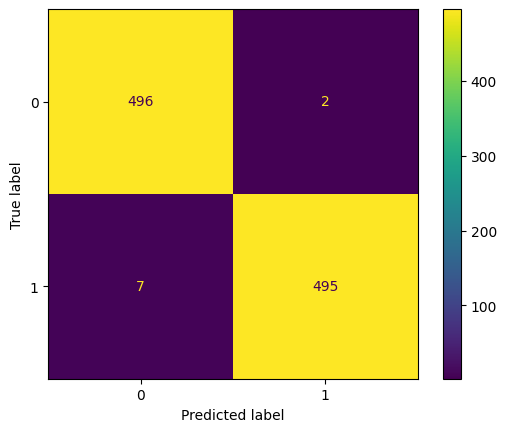

In [51]:
cm = confusion_matrix(y_test, y_pred_xgboost)
ConfusionMatrixDisplay(cm).plot()

In [74]:
# Para XGBoost
importance_xgb = xgboost.feature_importances_
features = X_train.columns
importance_df_xgb = pd.DataFrame({
    'Feature': features, 
    'Importance': importance_xgb
})
importance_df_xgb.sort_values(by='Importance', ascending=False)

,Feature,Importance
10,avg_watch_time_per_day,0.666612
3,watch_hours,0.096879
9,number_of_profiles,0.076848
4,last_login_days,0.074467
2,subscription_type,0.042757
8,payment_method,0.022923
7,monthly_fee,0.019316
11,favorite_genre,0.000119
0,age,0.000079
1,gender,0.000000


In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy score: Right predictions / total predictions - Formula: (TP + TN) / (TP + TN + FP + FN)
# Precision score: Right predictions / total predictions - Formula: TP / (TP + FP)
# Recall score: Right predictions / total predictions - Formula: TP / (TP + FN)
# F1 score: Harmonic mean of precision and recall - Formula: 2 * (precision * recall) / (precision + recall)


y_pred_list = [("Logistic Regression", y_pred_log_reg, log_reg), ("Random Forest", y_pred_random_forest, random_forest), ("XGBoost", y_pred_xgboost, xgboost)    ]

for model_name, y_pred, model in y_pred_list:
    print(f"Model: {model_name}")
    print(f"Accuracy score: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision score: {precision_score(y_test, y_pred, average='weighted'):.2f}")
    print(f"Recall score: {recall_score(y_test, y_pred, average='weighted'):.2f}")
    print(f"F1 score: {f1_score(y_test, y_pred, average='weighted'):.2f}")
    print("--------------------------------")



Model: Logistic Regression
Accuracy score: 0.88
Precision score: 0.88
Recall score: 0.88
F1 score: 0.88
--------------------------------
Model: Random Forest
Accuracy score: 0.98
Precision score: 0.98
Recall score: 0.98
F1 score: 0.98
--------------------------------
Model: XGBoost
Accuracy score: 0.99
Precision score: 0.99
Recall score: 0.99
F1 score: 0.99
--------------------------------


In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

for col in categorical_features:
    X[col] = label_encoder.fit_transform(X[col])
X_scaled = standard_scaler.fit_transform(X)

# Usar todo el dataset para CV
models = {
    'Logistic Regression': log_reg,
    'Random Forest': random_forest,
    'XGBoost': xgboost
}

# Métricas para evaluar
metrics = ['accuracy', 'precision', 'recall', 'f1']

for model_name, model in models.items():
    print(f"Model: {model_name}")
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calcular todas las métricas
    metric_scores = {}
    for metric in metrics:
        scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring=metric)
        metric_scores[metric] = (scores.mean(), scores.std())
    
    # Mostrar resultados
    for metric, (mean_score, std_score) in metric_scores.items():
        print(f"{metric.capitalize()}: {mean_score:.3f} (+/- {std_score * 2:.3f})")
    
    print("--------------------------------")

Model: Logistic Regression
Accuracy: 0.884 (+/- 0.018)
Precision: 0.880 (+/- 0.017)
Recall: 0.890 (+/- 0.020)
F1: 0.885 (+/- 0.016)
--------------------------------
Model: Random Forest
Accuracy: 0.973 (+/- 0.014)
Precision: 0.982 (+/- 0.008)
Recall: 0.964 (+/- 0.016)
F1: 0.972 (+/- 0.013)
--------------------------------
Model: XGBoost
Accuracy: 0.991 (+/- 0.010)
Precision: 0.998 (+/- 0.004)
Recall: 0.984 (+/- 0.017)
F1: 0.991 (+/- 0.009)
--------------------------------
